In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

import os
from dotenv import load_dotenv
load_dotenv()

True

# Modelo Baseline e Feature Importances

In [2]:
dir_path = os.environ['DATA_WRANGLING_ARTIFACT_PATH']
file_path = os.path.join(dir_path, 'processed_data_head.csv')
del dir_path

In [66]:
df = pd.read_csv(file_path)

In [4]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
clf = RandomForestClassifier(random_state=0)
clf.fit(X_train, y_train)
prediction = clf.predict(X_test)

In [8]:
print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1593
           1       0.77      0.47      0.58       407

    accuracy                           0.86      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.86      0.85      2000



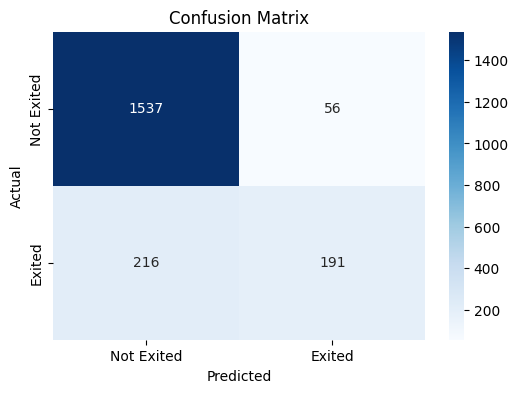

In [9]:
cm = confusion_matrix(y_test, prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


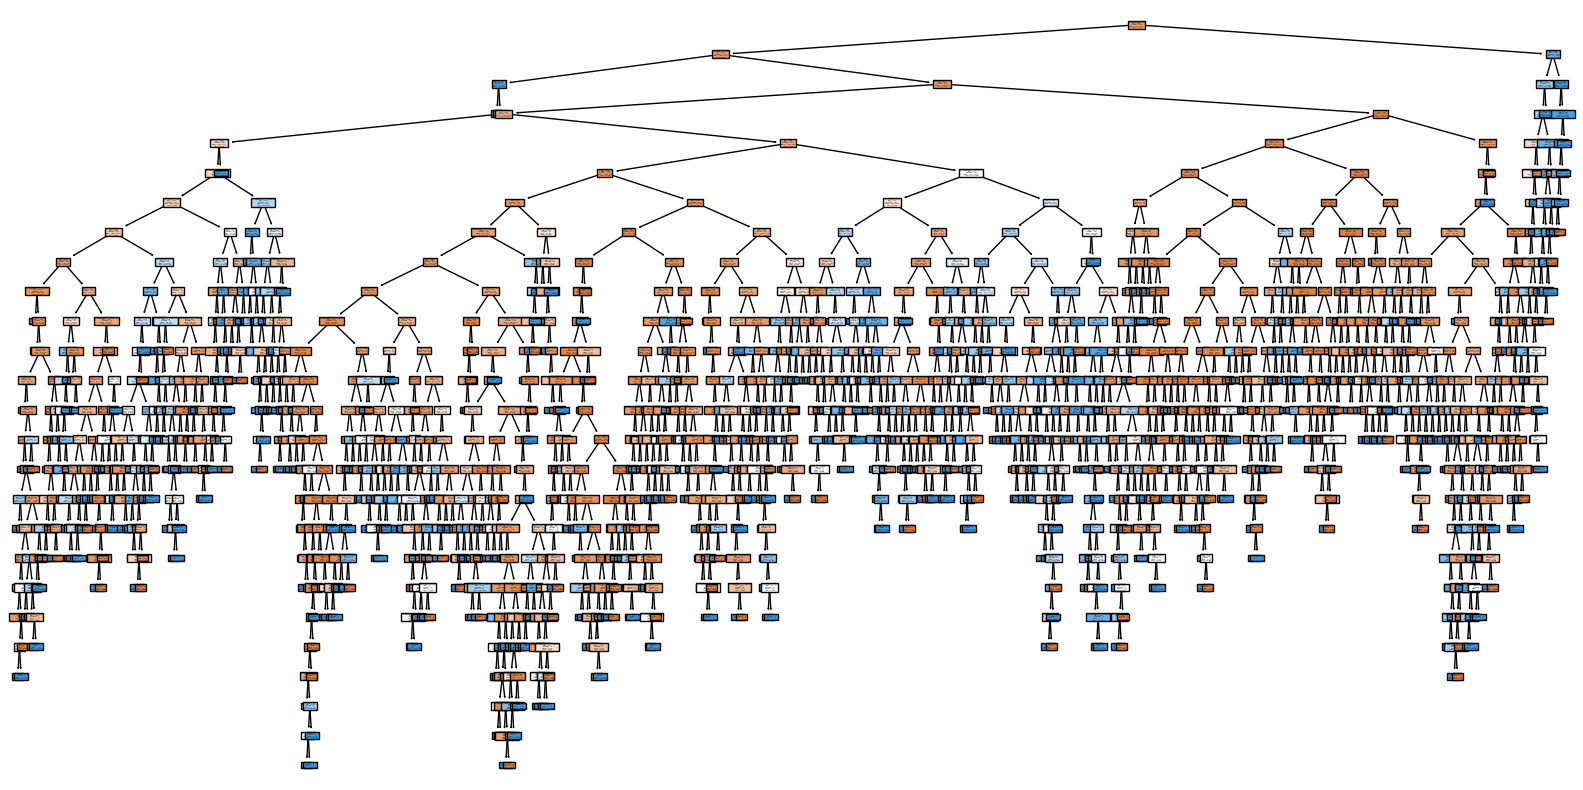

In [10]:
from sklearn.tree import plot_tree

fig, axes = plt.subplots(figsize=(20, 10))
plot_tree(
    decision_tree=clf.estimators_[1],
    feature_names=df.columns,
    class_names=['Exited', 'Not Exited'],
    filled=True,
    ax=axes
)
plt.show()

In [13]:
feature_importances_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

feature_importances_df

,Feature,Importance
0,Age,0.235319
1,EstimatedSalary,0.147366
2,CreditScore,0.143241
3,Balance,0.142890
4,NumOfProducts,0.131191
5,Tenure,0.079106
6,Geography,0.042938
7,IsActiveMember,0.040365
8,Gender,0.019279
9,HasCrCard,0.018303


# Feature Engineering

## Teste 1

In [ ]:
test1_df = df.drop(['HasCrCard', 'Tenure'], axis=1)

In [34]:
def execute_test_pipeline(df):
    X = df.drop('Exited', axis=1)
    y = df['Exited']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    clf = RandomForestClassifier(random_state=0)
    clf.fit(X_train, y_train)
    prediction = clf.predict(X_test)
    report = classification_report(y_test, prediction)

    cm = confusion_matrix(y_test, prediction)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return report

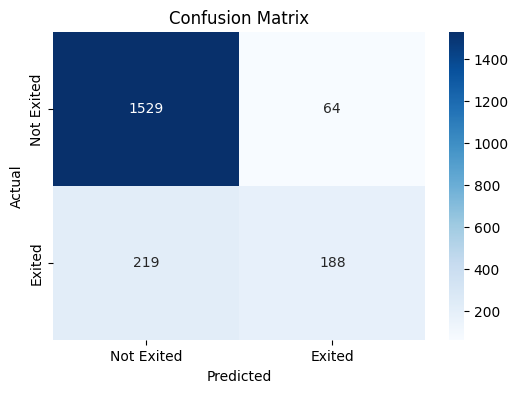

              precision    recall  f1-score   support

           0       0.87      0.96      0.92      1593
           1       0.75      0.46      0.57       407

    accuracy                           0.86      2000
   macro avg       0.81      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



In [ ]:
pipeline_result = execute_test_pipeline(test1_df)
print(pipeline_result)


## Teste 2

In [31]:
test2_df = df[feature_importances_df['Feature'].iloc[:5].values]
test2_df['Exited'] = df['Exited']
test2_df.head()

/tmp/ipykernel_82220/494907546.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test2_df['Exited'] = df['Exited']


,Age,EstimatedSalary,CreditScore,Balance,NumOfProducts,Exited
0,42,101348.88,619,0.00,1,1
1,41,112542.58,608,83807.86,1,0
2,42,113931.57,502,159660.80,3,1
3,39,93826.63,699,0.00,2,0
4,43,79084.10,850,125510.82,1,0


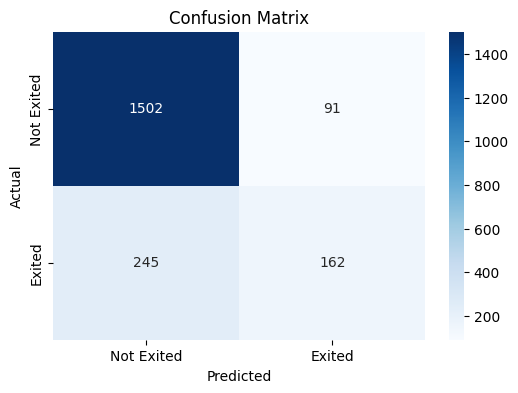

              precision    recall  f1-score   support

           0       0.86      0.94      0.90      1593
           1       0.64      0.40      0.49       407

    accuracy                           0.83      2000
   macro avg       0.75      0.67      0.70      2000
weighted avg       0.82      0.83      0.82      2000



In [37]:
pipeline_result = execute_test_pipeline(test2_df)
print(pipeline_result)


## Teste 3

In [41]:
test3_df = df[feature_importances_df['Feature'].iloc[:5].values]
test3_df['Exited'] = df['Exited']
test3_df.head()

/tmp/ipykernel_82220/2938456761.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df['Exited'] = df['Exited']


,Age,EstimatedSalary,CreditScore,Balance,NumOfProducts,Exited
0,42,101348.88,619,0.00,1,1
1,41,112542.58,608,83807.86,1,0
2,42,113931.57,502,159660.80,3,1
3,39,93826.63,699,0.00,2,0
4,43,79084.10,850,125510.82,1,0


In [ ]:
# Segmentação de idade para a coluna Age
bins = [0, 29, 39, 49, 59, 150]
labels = ['<30', '30-39', '40-49', '50-59', '60+']
test3_df['AgeGroup'] = pd.cut(test3_df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Categorização
agegroup_dict = {
    '<30': 0,
    '30-39': 1,
    '40-49': 2,
    '50-59': 3,
    '60+': 4
}
test3_df['AgeGroup'] = test3_df['AgeGroup'].map(agegroup_dict)

# Visualizar a contagem de cada grupo de idade
print(test3_df['AgeGroup'].value_counts())


AgeGroup
1    4346
2    2618
0    1641
3     869
4     526
Name: count, dtype: int64


/tmp/ipykernel_82220/2202638654.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df['AgeGroup'] = pd.cut(test3_df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)
/tmp/ipykernel_82220/2202638654.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df['AgeGroup'] = test3_df['AgeGroup'].map(agegroup_dict)


In [47]:
# Segmentação de CreditScore para a coluna CreditScore
credit_bins = [0, 580, 670, 740, 800, 1000]
credit_labels = ['Ruim', 'Regular', 'Bom', 'Muito Bom', 'Excelente']
test3_df['CreditScoreGroup'] = pd.cut(test3_df['CreditScore'], bins=credit_bins, labels=credit_labels, right=True, include_lowest=True)

# Categorização de CreditScore a partir de um dicionário
creditscore_dict = {
    'Ruim': 0,
    'Regular': 1,
    'Bom': 2,
    'Muito Bom': 3,
    'Excelente': 4
}
test3_df['CreditScoreGroup'] = test3_df['CreditScoreGroup'].map(creditscore_dict)
print(test3_df['CreditScoreGroup'].value_counts())


CreditScoreGroup
1    3350
2    2397
0    2393
3    1215
4     645
Name: count, dtype: int64


/tmp/ipykernel_82220/3224029756.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df['CreditScoreGroup'] = pd.cut(test3_df['CreditScore'], bins=credit_bins, labels=credit_labels, right=True, include_lowest=True)
/tmp/ipykernel_82220/3224029756.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df['CreditScoreGroup'] = test3_df['CreditScoreGroup'].map(creditscore_dict)


In [52]:
test3_df.drop(['Age', 'CreditScore'], axis=1, inplace=True)

/tmp/ipykernel_82220/1588834661.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test3_df.drop(['Age', 'CreditScore'], axis=1, inplace=True)


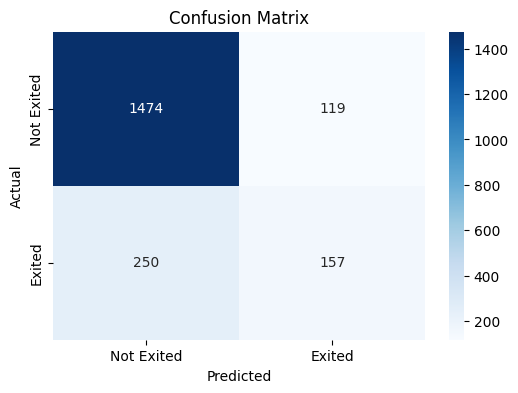

              precision    recall  f1-score   support

           0       0.85      0.93      0.89      1593
           1       0.57      0.39      0.46       407

    accuracy                           0.82      2000
   macro avg       0.71      0.66      0.67      2000
weighted avg       0.80      0.82      0.80      2000



In [54]:
pipeline_result = execute_test_pipeline(test3_df)
print(pipeline_result)


## Teste 4

In [ ]:
test4_df = df.copy()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,1,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,1,0,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
def execute_test_pipeline(df):
    X = df.drop('Exited', axis=1)
    y = df['Exited']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

    print("Distribuição no conjunto de treino original:", Counter(y_train))
    print("Distribuição no conjunto de teste:", Counter(y_test))

    # 2. Aplicar downsampling SOMENTE nos dados de treino
    rus = RandomUnderSampler(random_state=42)
    X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

    print("\nDistribuição no conjunto de treino após downsampling:", Counter(y_train_resampled))

    clf = RandomForestClassifier(random_state=0)
    clf.fit(X_train_resampled, y_train_resampled)
    prediction = clf.predict(X_test)
    report = classification_report(y_test, prediction)

    cm = confusion_matrix(y_test, prediction)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Exited', 'Exited'], yticklabels=['Not Exited', 'Exited'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    return report

Distribuição no conjunto de treino original: Counter({0: 6370, 1: 1630})
Distribuição no conjunto de teste: Counter({0: 1593, 1: 407})

Distribuição no conjunto de treino após downsampling: Counter({0: 1630, 1: 1630})


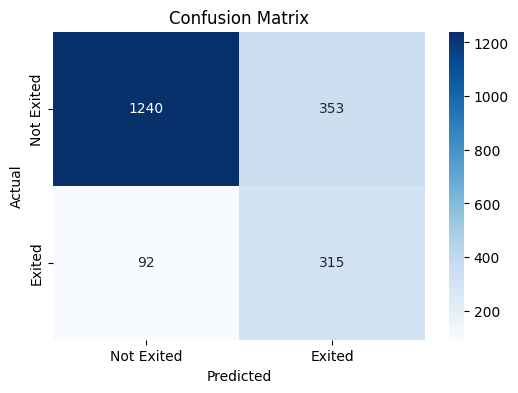

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1593
           1       0.47      0.77      0.59       407

    accuracy                           0.78      2000
   macro avg       0.70      0.78      0.72      2000
weighted avg       0.84      0.78      0.79      2000



In [73]:
pipeline_result = execute_test_pipeline(test4_df)
print(pipeline_result)

## Teste 5

In [ ]:
test5_df = df.copy()
test5_df = test5_df[feature_importances_df['Feature'].iloc[:5].values]
test5_df['Exited'] = df['Exited']
test5_df.head()

,Age,EstimatedSalary,CreditScore,Balance,NumOfProducts,Exited
0,42,101348.88,619,0.00,1,1
1,41,112542.58,608,83807.86,1,0
2,42,113931.57,502,159660.80,3,1
3,39,93826.63,699,0.00,2,0
4,43,79084.10,850,125510.82,1,0


Distribuição no conjunto de treino original: Counter({0: 6370, 1: 1630})
Distribuição no conjunto de teste: Counter({0: 1593, 1: 407})

Distribuição no conjunto de treino após downsampling: Counter({0: 1630, 1: 1630})


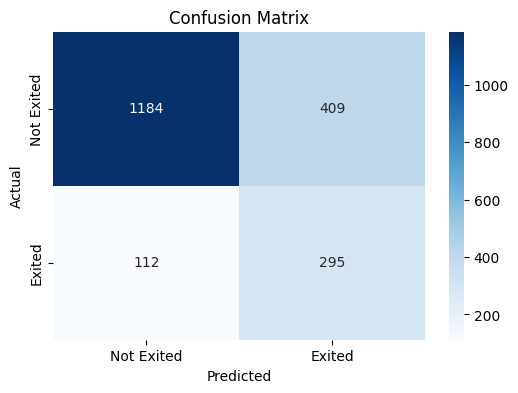

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1593
           1       0.42      0.72      0.53       407

    accuracy                           0.74      2000
   macro avg       0.67      0.73      0.68      2000
weighted avg       0.81      0.74      0.76      2000



In [74]:
pipeline_result = execute_test_pipeline(test5_df)
print(pipeline_result)

## Teste 6

In [81]:
test6_df = df.copy()

In [82]:
# Segmentação de idade para a coluna Age
bins = [0, 29, 39, 49, 59, 150]
labels = ['<30', '30-39', '40-49', '50-59', '60+']
test6_df['AgeGroup'] = pd.cut(test6_df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Categorização
agegroup_dict = {
    '<30': 0,
    '30-39': 1,
    '40-49': 2,
    '50-59': 3,
    '60+': 4
}
test6_df['AgeGroup'] = test6_df['AgeGroup'].map(agegroup_dict)

# Visualizar a contagem de cada grupo de idade
print(test6_df['AgeGroup'].value_counts())

AgeGroup
1    4346
2    2618
0    1641
3     869
4     526
Name: count, dtype: int64


In [83]:
# Segmentação de CreditScore para a coluna CreditScore
credit_bins = [0, 580, 670, 740, 800, 1000]
credit_labels = ['Ruim', 'Regular', 'Bom', 'Muito Bom', 'Excelente']
test6_df['CreditScoreGroup'] = pd.cut(test6_df['CreditScore'], bins=credit_bins, labels=credit_labels, right=True, include_lowest=True)

# Categorização de CreditScore a partir de um dicionário
creditscore_dict = {
    'Ruim': 0,
    'Regular': 1,
    'Bom': 2,
    'Muito Bom': 3,
    'Excelente': 4
}
test6_df['CreditScoreGroup'] = test6_df['CreditScoreGroup'].map(creditscore_dict)
print(test6_df['CreditScoreGroup'].value_counts())

CreditScoreGroup
1    3350
2    2397
0    2393
3    1215
4     645
Name: count, dtype: int64


In [84]:
# Segmentação de Tenure para a coluna Tenure
tenure_bins = [0, 2, 5, 8, 10]
tenure_labels = ['0-2', '3-5', '6-8', '9-10']
test6_df['TenureGroup'] = pd.cut(test6_df['Tenure'], bins=tenure_bins, labels=tenure_labels, right=True, include_lowest=True)

# Categorização de Tenure a partir de um dicionário
tenure_dict = {
    '0-2': 0,
    '3-5': 1,
    '6-8': 2,
    '9-10': 3
}
test6_df['TenureGroup'] = test6_df['TenureGroup'].map(tenure_dict)

# Visualizar a contagem de cada grupo de Tenure
print(test6_df['TenureGroup'].value_counts())


TenureGroup
2    3020
1    3010
0    2496
3    1474
Name: count, dtype: int64


In [85]:
test6_df.drop(['Age', 'CreditScore', 'Tenure'], axis=1, inplace=True)

Distribuição no conjunto de treino original: Counter({0: 6370, 1: 1630})
Distribuição no conjunto de teste: Counter({0: 1593, 1: 407})

Distribuição no conjunto de treino após downsampling: Counter({0: 1630, 1: 1630})


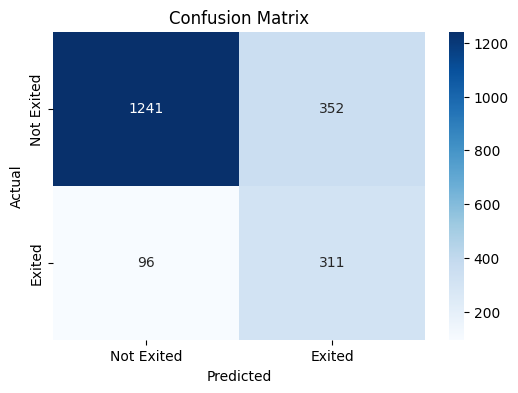

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1593
           1       0.47      0.76      0.58       407

    accuracy                           0.78      2000
   macro avg       0.70      0.77      0.71      2000
weighted avg       0.83      0.78      0.79      2000



In [86]:
pipeline_result = execute_test_pipeline(test6_df)
print(pipeline_result)

## Teste 7

In [99]:
test7_df = df.copy()

In [100]:
# Segmentação de idade para a coluna Age
bins = [0, 29, 39, 49, 59, 150]
labels = ['<30', '30-39', '40-49', '50-59', '60+']
test7_df['AgeGroup'] = pd.cut(test7_df['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

# Categorização
agegroup_dict = {
    '<30': 0,
    '30-39': 1,
    '40-49': 2,
    '50-59': 3,
    '60+': 4
}
test7_df['AgeGroup'] = test7_df['AgeGroup'].map(agegroup_dict)

# Visualizar a contagem de cada grupo de idade
print(test7_df['AgeGroup'].value_counts())

AgeGroup
1    4346
2    2618
0    1641
3     869
4     526
Name: count, dtype: int64


In [101]:
# Segmentação de CreditScore para a coluna CreditScore
credit_bins = [0, 580, 670, 740, 800, 1000]
credit_labels = ['Ruim', 'Regular', 'Bom', 'Muito Bom', 'Excelente']
test7_df['CreditScoreGroup'] = pd.cut(test7_df['CreditScore'], bins=credit_bins, labels=credit_labels, right=True, include_lowest=True)

# Categorização de CreditScore a partir de um dicionário
creditscore_dict = {
    'Ruim': 0,
    'Regular': 1,
    'Bom': 2,
    'Muito Bom': 3,
    'Excelente': 4
}
test7_df['CreditScoreGroup'] = test7_df['CreditScoreGroup'].map(creditscore_dict)
print(test7_df['CreditScoreGroup'].value_counts())

CreditScoreGroup
1    3350
2    2397
0    2393
3    1215
4     645
Name: count, dtype: int64


In [102]:
# Segmentação de Tenure para a coluna Tenure
tenure_bins = [0, 2, 5, 8, 10]
tenure_labels = ['0-2', '3-5', '6-8', '9-10']
test7_df['TenureGroup'] = pd.cut(test7_df['Tenure'], bins=tenure_bins, labels=tenure_labels, right=True, include_lowest=True)

# Categorização de Tenure a partir de um dicionário
tenure_dict = {
    '0-2': 0,
    '3-5': 1,
    '6-8': 2,
    '9-10': 3
}
test7_df['TenureGroup'] = test7_df['TenureGroup'].map(tenure_dict)

# Visualizar a contagem de cada grupo de Tenure
print(test7_df['TenureGroup'].value_counts())


TenureGroup
2    3020
1    3010
0    2496
3    1474
Name: count, dtype: int64


In [103]:
test7_df['Services_per_Tenure'] = test7_df['NumOfProducts'] / (test7_df['Tenure'] + 1)

In [104]:
test7_df.drop(['Age', 'CreditScore', 'Tenure'], axis=1, inplace=True)

Distribuição no conjunto de treino original: Counter({0: 6370, 1: 1630})
Distribuição no conjunto de teste: Counter({0: 1593, 1: 407})

Distribuição no conjunto de treino após downsampling: Counter({0: 1630, 1: 1630})


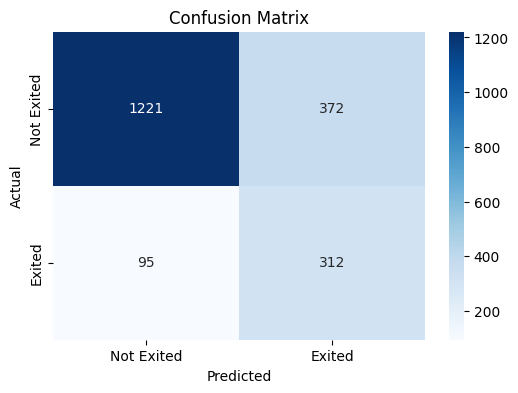

              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.77      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



In [106]:
pipeline_result = execute_test_pipeline(test7_df)
print(pipeline_result)

## Teste 8

In [ ]:
test8_df = test7_df.copy()

,Geography,Gender,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,CreditScoreGroup,TenureGroup,Services_per_Tenure
0,0,0,0.00,1,1,1,101348.88,1,2,1,0,0.333333
1,1,0,83807.86,1,0,1,112542.58,0,2,1,0,0.500000
2,0,0,159660.80,3,1,0,113931.57,1,2,0,2,0.333333
3,0,0,0.00,2,0,0,93826.63,0,1,2,0,1.000000
4,1,0,125510.82,1,1,1,79084.10,0,2,4,0,0.333333


In [110]:
scaler = MinMaxScaler()
test8_df[['Balance', 'EstimatedSalary']] = scaler.fit_transform(test8_df[['Balance', 'EstimatedSalary']])

Distribuição no conjunto de treino original: Counter({0: 6370, 1: 1630})
Distribuição no conjunto de teste: Counter({0: 1593, 1: 407})

Distribuição no conjunto de treino após downsampling: Counter({0: 1630, 1: 1630})


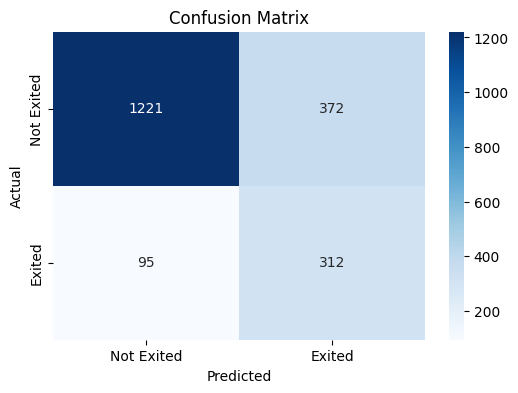

              precision    recall  f1-score   support

           0       0.93      0.77      0.84      1593
           1       0.46      0.77      0.57       407

    accuracy                           0.77      2000
   macro avg       0.69      0.77      0.71      2000
weighted avg       0.83      0.77      0.79      2000



In [111]:
pipeline_result = execute_test_pipeline(test7_df)
print(pipeline_result)